In [1]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (50000, 32)

First 5 Rows:


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nDuplicate Rows:", df.duplicated().sum())

Columns:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              50000 non-null  object 
 5   Specialisation      50000 non-null 

In [5]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
StudentID,50000.0,NaN,NaN,NaN,25000.5,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
Gender,50000,2,Male,30133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,50000,10,Hyderabad,8114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CollegeTier,50000,3,Tier2,23315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stream,50000,6,CS,13937,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Specialisation,50000,4,Embedded,13614,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hostel,50000,2,Yes,27785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HistoryOfBacklogs,50000,2,No,40893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SGPA_Sem1,50000.0,NaN,NaN,NaN,7.210583,1.517846,4.0,6.09,7.19,8.34,10.0
SGPA_Sem2,50000.0,NaN,NaN,NaN,7.222243,1.532008,4.0,6.09,7.21,8.36,10.0


Placement Status Distribution:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64

Placement Status Percentage:
PlacementStatus
1    65.712
0    34.288
Name: proportion, dtype: float64


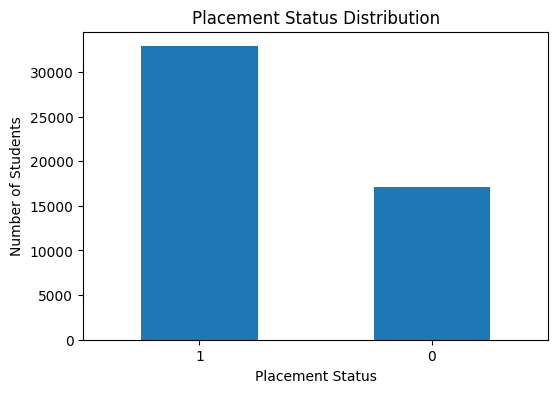

In [6]:
print("Placement Status Distribution:")
print(df["PlacementStatus"].value_counts())

print("\nPlacement Status Percentage:")
print(df["PlacementStatus"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
df["PlacementStatus"].value_counts().plot(kind="bar")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.title("Placement Status Distribution")
plt.xticks(rotation=0)
plt.show()

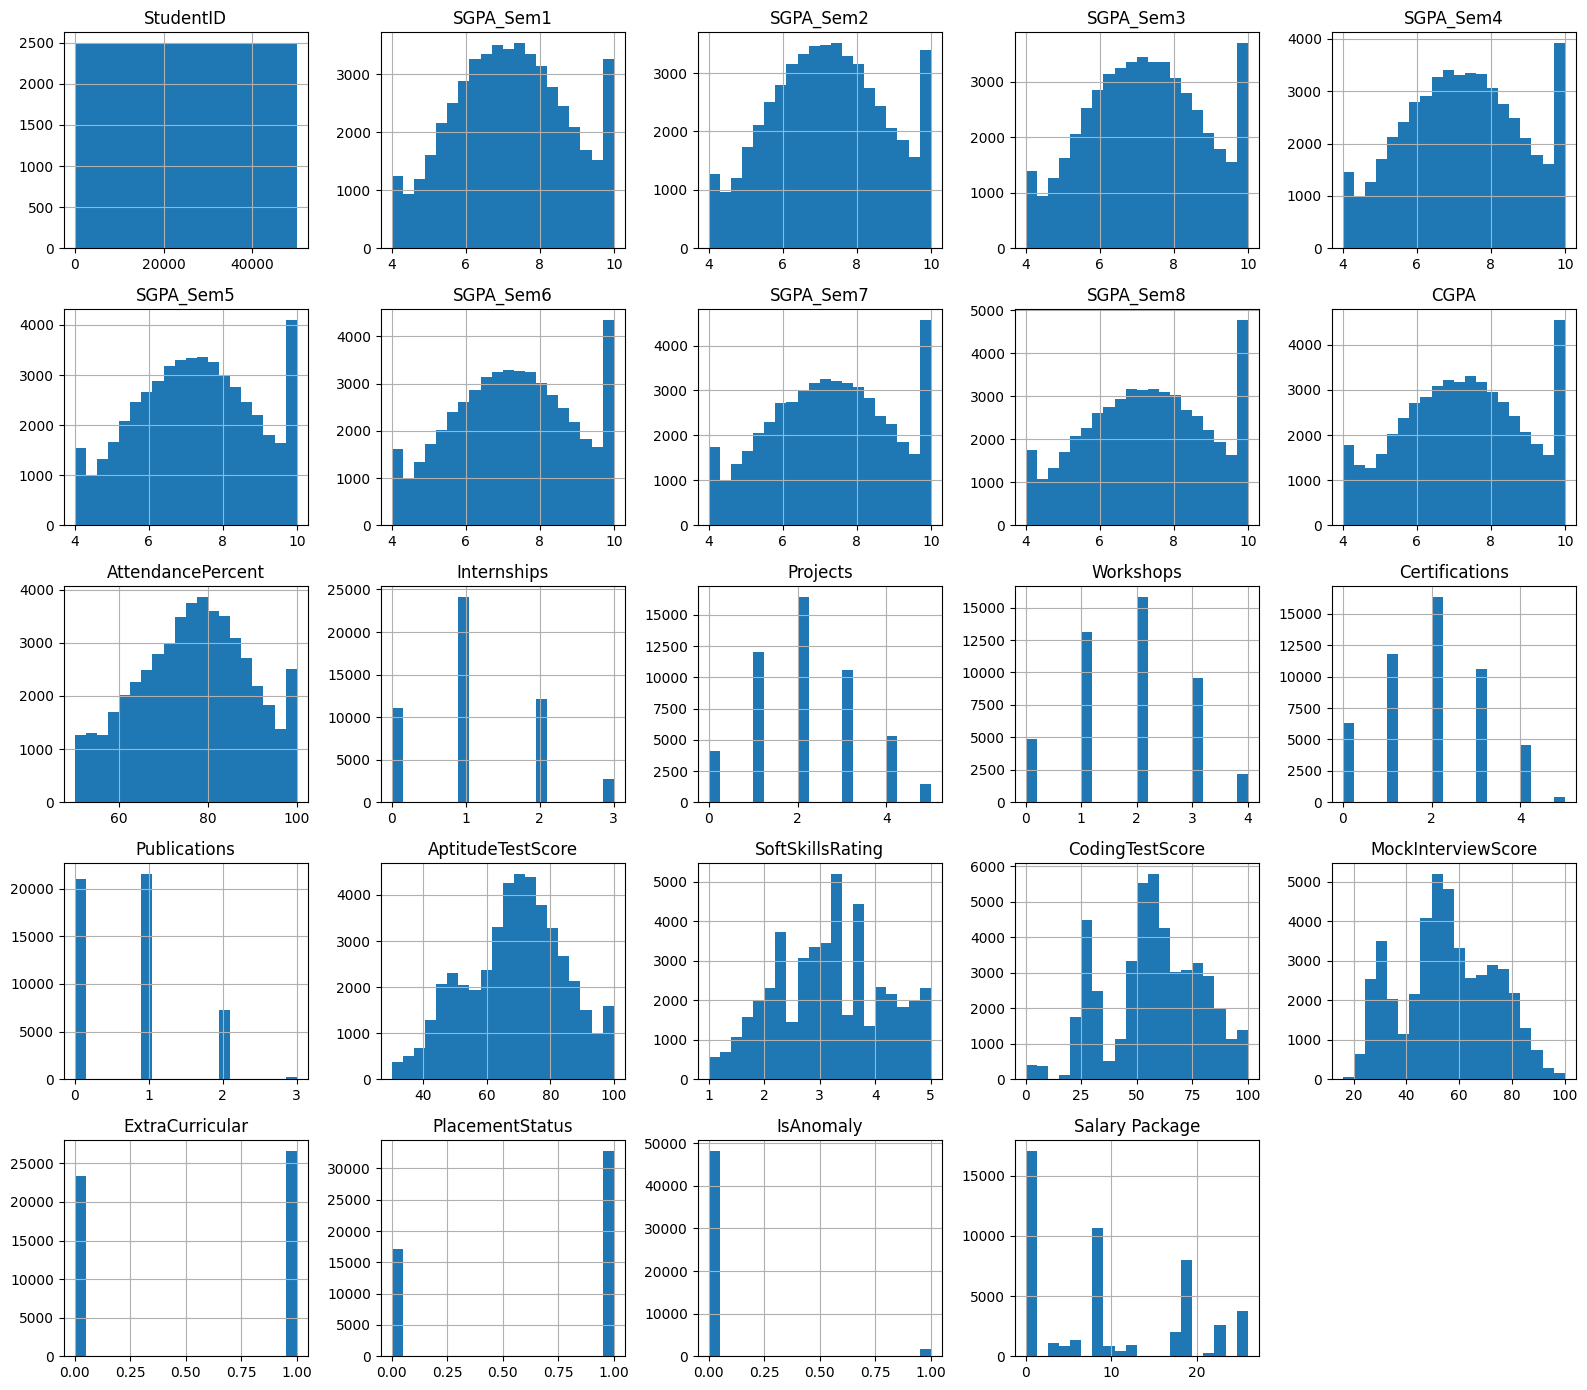

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    figsize=(16, 14),
    bins=20
)

plt.tight_layout()
plt.show()

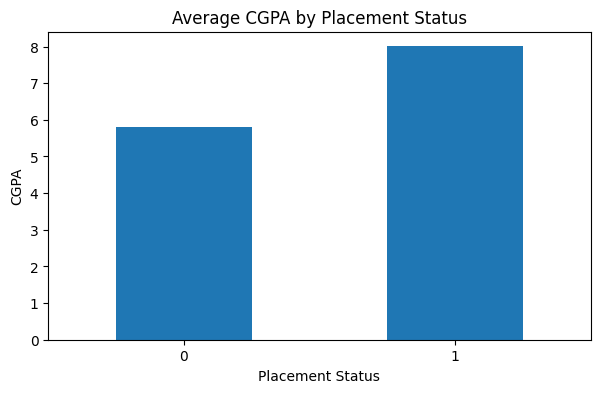

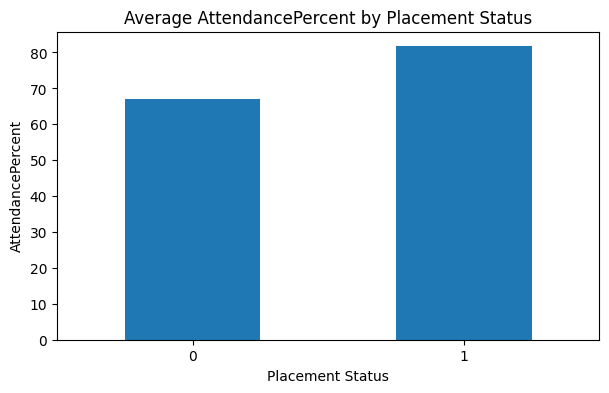

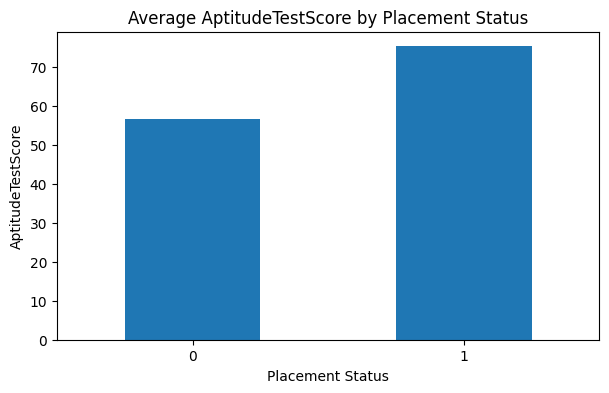

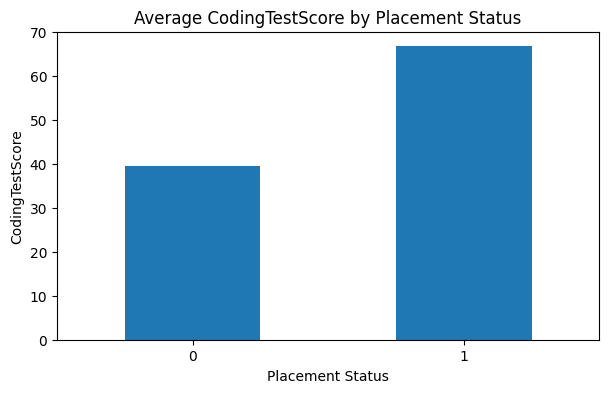

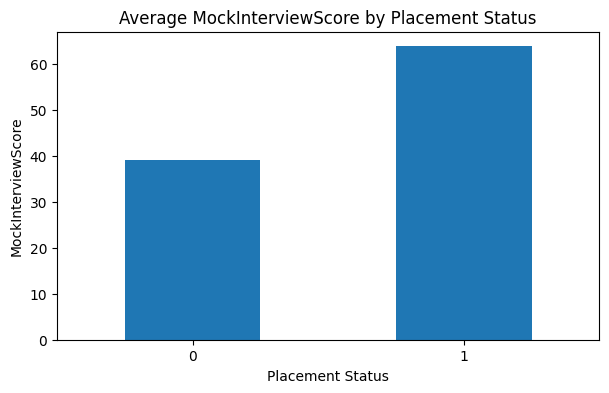

In [8]:
features = [
    "CGPA",
    "AttendancePercent",
    "AptitudeTestScore",
    "CodingTestScore",
    "MockInterviewScore"
]

for feature in features:
    plt.figure(figsize=(7, 4))
    df.groupby("PlacementStatus")[feature].mean().plot(kind="bar")
    plt.title(f"Average {feature} by Placement Status")
    plt.xlabel("Placement Status")
    plt.ylabel(feature)
    plt.xticks(rotation=0)
    plt.show()

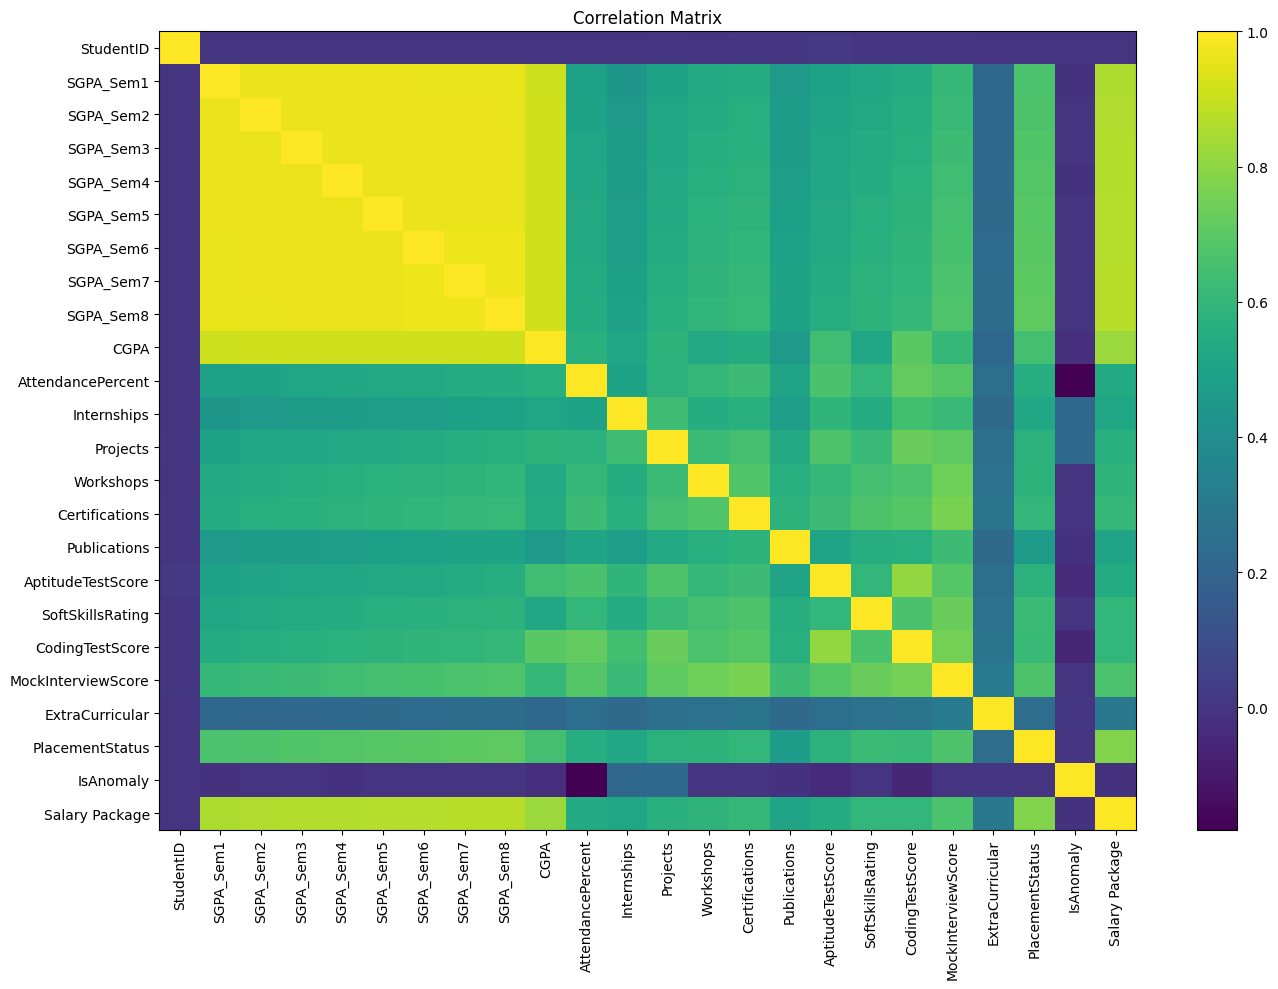

In [9]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(14, 10))
plt.imshow(correlation, aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [10]:
target = "PlacementStatus"

drop_columns = [
    "StudentID",
    "Salary Package"
]

X = df.drop(columns=[target] + drop_columns)
y = df[target]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nTarget Distribution:")
print(y.value_counts())

Feature Shape: (50000, 29)
Target Shape: (50000,)

Target Distribution:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (40000, 29)
Testing Data: (10000, 29)


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Numerical Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))

Numerical Features: 21
Categorical Features: 8


In [13]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.9211

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      3429
           1       0.93      0.95      0.94      6571

    accuracy                           0.92     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.92      0.92     10000


Confusion Matrix:
[[2941  488]
 [ 301 6270]]


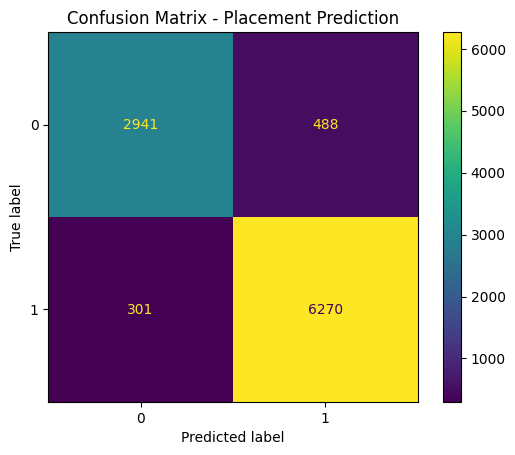

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix - Placement Prediction")
plt.show()

In [16]:
print("""
ML LIFECYCLE MAPPING

1. Problem Definition
   Predict whether a student will be placed.

2. Data Collection
   placement_predict_50k Dataset.csv

3. Data Understanding
   50,000 records and 32 columns.

4. Exploratory Data Analysis
   Missing values, distributions, target distribution and correlations.

5. Data Preprocessing
   Missing-value imputation, encoding and feature scaling.

6. Data Splitting
   80% training and 20% testing.

7. Model Training
   Logistic Regression.

8. Model Evaluation
   Accuracy, precision, recall, F1-score and confusion matrix.

9. Final Output
   PlacementStatus prediction.
""")


ML LIFECYCLE MAPPING

1. Problem Definition
   Predict whether a student will be placed.

2. Data Collection
   placement_predict_50k Dataset.csv

3. Data Understanding
   50,000 records and 32 columns.

4. Exploratory Data Analysis
   Missing values, distributions, target distribution and correlations.

5. Data Preprocessing
   Missing-value imputation, encoding and feature scaling.

6. Data Splitting
   80% training and 20% testing.

7. Model Training
   Logistic Regression.

8. Model Evaluation
   Accuracy, precision, recall, F1-score and confusion matrix.

9. Final Output
   PlacementStatus prediction.

